In [27]:
import pandas as pd
import matplotlib.pyplot as plt

class Action:

    def __init__(self, log_file: str):
        """
        Charge le fichier CSV et prépare le DataFrame.
        """
        self.df = pd.read_csv(log_file)

        # Convertir la date si elle existe
        if "date" in self.df.columns:
            self.df["date"] = pd.to_datetime(self.df["date"], errors="coerce")


    def compute_nb_by_user(self):
        """
        Calcule le nombre d'actions par utilisateur.
        -> équivalent Controller
        """
        stats = self.df.groupby("pseudo").size().reset_index(name="nb_actions")
        return stats


    def plot_histogram(self):
        """
        Affiche un histogramme du nombre d'actions par utilisateur.
        -> équivalent View
        """
        stats = self.compute_nb_by_user()
        stats.sort_values("nb_actions", ascending=False, inplace=True)
        plt.figure(figsize=(10, 6))
        plt.bar(stats["pseudo"].astype(str), stats["nb_actions"])
        plt.xlabel("Pseudo utilisateur")
        plt.ylabel("Nombre d’actions")
        plt.title("Histogramme du nombre d’actions par utilisateur")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()



In [28]:
ac = Action("logs_anonymises.csv")

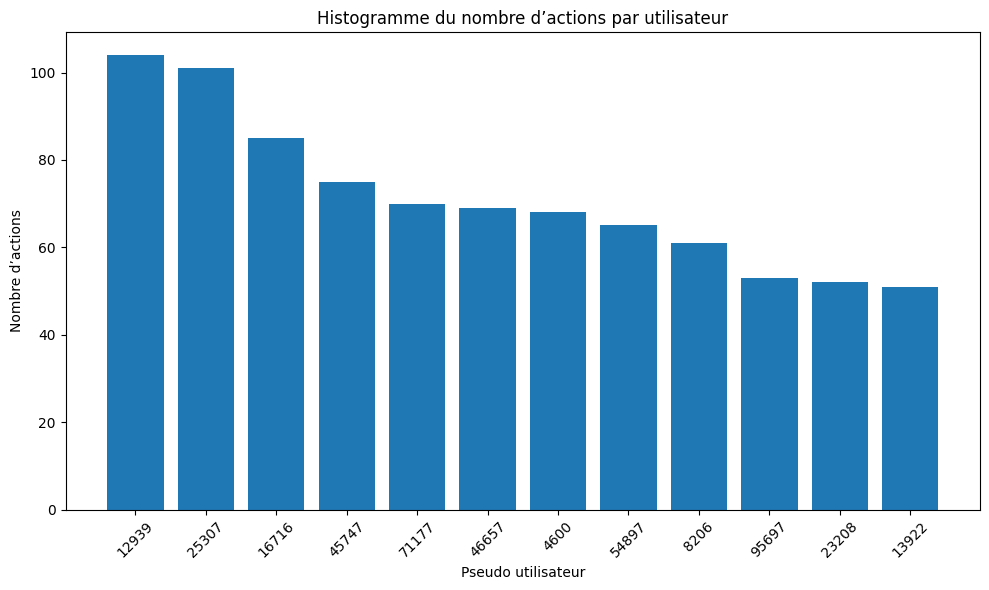

In [30]:
ac.plot_histogram()